In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/MU projekat/konacni.csv')

In [ ]:
class_column = 'Credit_Mix'

total_instances = len(df)

# Ciljana veličina dataset-a (20% originalne veličine)
target_size = int(total_instances * 0.2)

# Izračunaj broj instanci po klasi proporcionalno početnom omjeru
class_counts = df[class_column].value_counts()
class_proportions = class_counts / total_instances
target_class_counts = (class_proportions * target_size).astype(int)

# Provjera ciljanog broja instanci po klasi
print("Ciljani broj instanci po klasi:")
print(target_class_counts)

# Kreiraj praznu listu za čuvanje podskupova
reduced_dfs = []

# Uzmi slučajan uzorak za svaku klasu proporcionalno ciljanom broju
for cls, count in target_class_counts.items():
    class_subset = df[df[class_column] == cls].sample(n=count, random_state=42)
    reduced_dfs.append(class_subset)

# Spoji podskupove u jedan dataframe
df = pd.concat(reduced_dfs, axis=0)

# Provjera nove distribucije klasa
print("Broj instanci po klasi nakon smanjenja:")
print(df[class_column].value_counts())

# Opcionalno: Provjeri konačnu veličinu
print("Konačna veličina dataset-a:", len(df))

Ciljani broj instanci po klasi:
Credit_Mix
Standard    11150
Good         4794
Bad          3741
Name: count, dtype: int64
Broj instanci po klasi nakon smanjenja:
Credit_Mix
Standard    11150
Good         4794
Bad          3741
Name: count, dtype: int64
Konačna veličina dataset-a: 19685


In [ ]:
df.drop('Credit_Score', axis=1, inplace=True)

month_mode = df['Occupation'].mode()[0]
df['Occupation'] = df['Occupation'].fillna(month_mode)

amount_median = df['Amount_invested_monthly'].median()
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].fillna(amount_median)

# Label encoding za sve kategoričke varijable
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = encoder.fit_transform(df[col])  # Kodiranje i prepisivanje originalne kolone

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19685 entries, 66180 to 51613
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     19685 non-null  int64  
 1   Occupation                19685 non-null  int64  
 2   Annual_Income             19685 non-null  float64
 3   Num_Bank_Accounts         19685 non-null  int64  
 4   Num_Credit_Card           19685 non-null  float64
 5   Interest_Rate             19685 non-null  float64
 6   Num_of_Loan               19685 non-null  float64
 7   Delay_from_due_date       19685 non-null  int64  
 8   Num_of_Delayed_Payment    19685 non-null  float64
 9   Changed_Credit_Limit      19685 non-null  float64
 10  Num_Credit_Inquiries      19685 non-null  float64
 11  Credit_Mix                19685 non-null  int64  
 12  Outstanding_Debt          19685 non-null  float64
 13  Credit_Utilization_Ratio  19685 non-null  float64
 14  Credit_

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data = scaler.fit_transform(df)

In [ ]:
data.shape

(19685, 30)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.90)
data_pca = pca.fit_transform(data)

In [ ]:
print(f"Broj zadržanih komponenti: {pca.n_components_}")

Broj zadržanih komponenti: 23


In [ ]:
data_pca.shape

(19685, 23)

In [ ]:
print(pca.explained_variance_ratio_)

[0.20042807 0.05474766 0.04902333 0.04588973 0.04001251 0.03388399
 0.03358578 0.03327076 0.03235136 0.03186809 0.03170276 0.0313216
 0.03095634 0.03084586 0.03042541 0.0299665  0.02929047 0.02861531
 0.02516009 0.02436048 0.02322129 0.0215836  0.02060228]


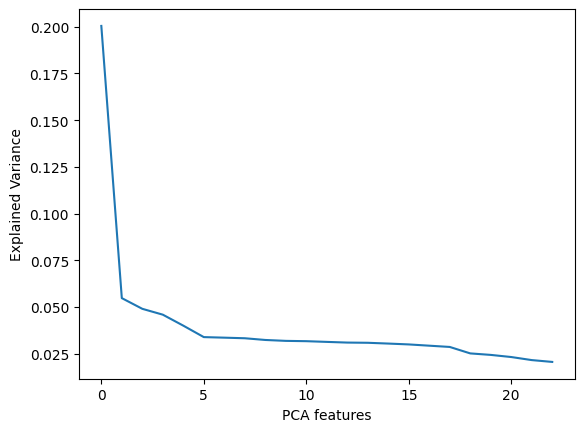

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(0,len(pca.explained_variance_)),
pca.explained_variance_ratio_)
plt.xlabel("PCA features")
plt.ylabel("Explained Variance")
plt.show()

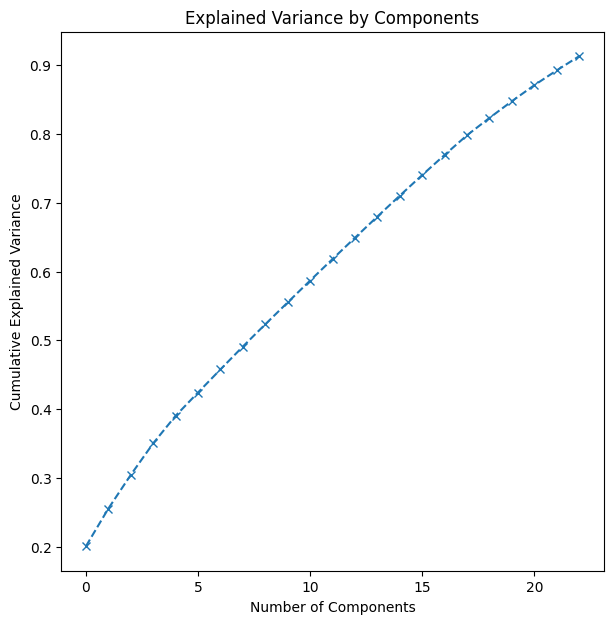

In [ ]:
#kumulativni  prikaz varijanse po komponentama
plt.figure(figsize=(7,7))
plt.plot(range(0,23),
pca.explained_variance_ratio_.cumsum(),
marker='x',linestyle='--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

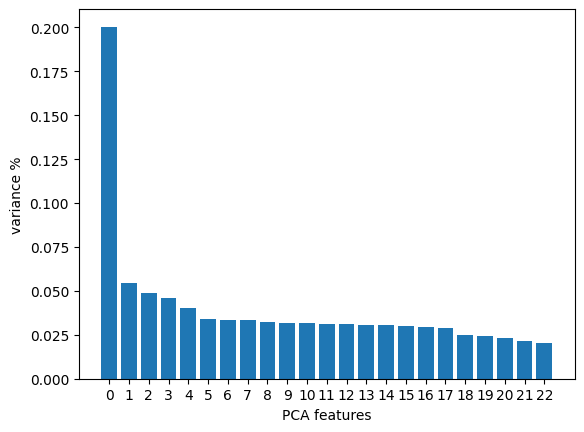

In [ ]:
#kumulativni  prikaz varijanse po komponentama
features=range(pca.n_components_)
plt.bar(features,pca.explained_variance_ratio_)
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.xticks(features)
plt.show()

In [ ]:
!pip install scikit-learn-extra

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 29.2 MB/s eta 0:00:00


Silhouette Score for 2 clusters: 0.02556024947123615
Silhouette Score for 3 clusters: 0.0247353535387117
Silhouette Score for 4 clusters: 0.015708504245851067
Silhouette Score for 5 clusters: 0.05432751372422301
Silhouette Score for 6 clusters: 0.05141972394390492
Silhouette Score for 7 clusters: 0.02697745165186498
Silhouette Score for 8 clusters: 0.041161308646255654
Silhouette Score for 9 clusters: 0.03966164318200439
Silhouette Score for 10 clusters: 0.03382580177535243


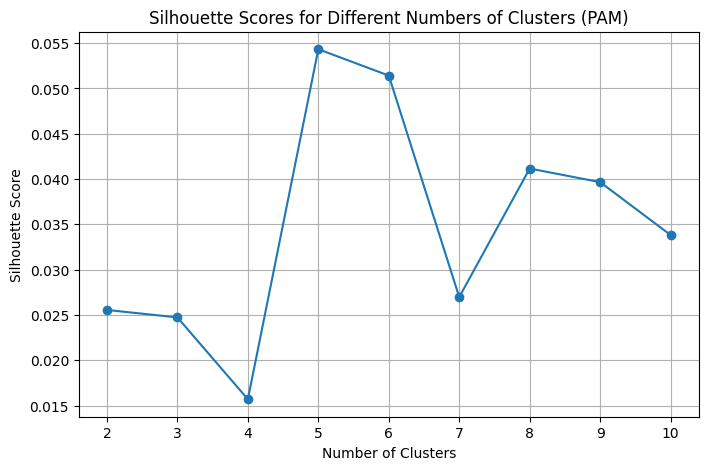

In [ ]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

silhouette_scores = []
k = range(2, 11)

for n_clusters in k:
    pam = KMedoids(n_clusters=n_clusters, random_state=42)
    cluster_labels = pam.fit_predict(data_pca)
    silhouette_avg = silhouette_score(data_pca, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Silhouette Score for {n_clusters} clusters: {silhouette_avg}")

plt.figure(figsize=(8, 5))
plt.plot(k, silhouette_scores, marker='o')
plt.xticks(k)
plt.title('Silhouette Scores for Different Numbers of Clusters (PAM)')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

optimal_k = k[np.argmax(silhouette_scores)]
print("Optimalan broj klastera:", optimal_k)

Optimalan broj klastera: 5


In [ ]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

optimal_k = 5
kmedoids = KMedoids(n_clusters=optimal_k, random_state=42).fit(data_pca)
cluster_labels = kmedoids.labels_

In [ ]:
df['Cluster'] = cluster_labels

In [ ]:
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(df, cluster_labels)

In [ ]:
print(ch_score)

55.52111907992524


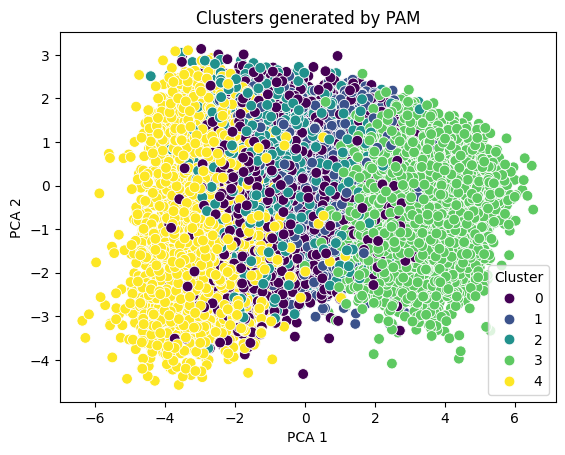

In [ ]:
import seaborn as sns

sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=cluster_labels, palette='viridis', s=60)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters generated by PAM')
plt.legend(title='Cluster')
plt.show()

In [ ]:
silhouette_avg = silhouette_score(data_pca, cluster_labels)
print(f"Prosječni silhouette koeficijent za klastere: {silhouette_avg:.2f}")

Prosječni silhouette koeficijent za klastere: 0.05


In [ ]:
n_components = data_pca.shape[1]

pca_df = pd.DataFrame(data_pca, columns=[f'PC{i+1}' for i in range(n_components)])

# Save the transformed data to a CSV file
pca_df.to_csv('/content/pca_result.csv', index=False)

In [ ]:
pca = PCA(n_components=0.50)
data_pca = pca.fit_transform(data)

In [ ]:
print(f"Broj zadržanih komponenti: {pca.n_components_}")

Broj zadržanih komponenti: 9


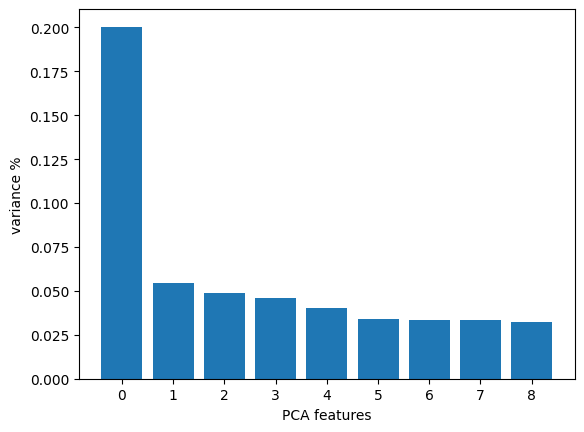

In [ ]:
#kumulativni  prikaz varijanse po komponentama
features=range(pca.n_components_)
plt.bar(features,pca.explained_variance_ratio_)
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.xticks(features)
plt.show()

Silhouette Score for 2 clusters: 0.25628922791147424
Silhouette Score for 3 clusters: 0.15509842588842349
Silhouette Score for 4 clusters: 0.13545098053306365
Silhouette Score for 5 clusters: 0.13160202294333576
Silhouette Score for 6 clusters: 0.12341469213132938
Silhouette Score for 7 clusters: 0.1151629936856054
Silhouette Score for 8 clusters: 0.11033026401974827
Silhouette Score for 9 clusters: 0.1046022658125371
Silhouette Score for 10 clusters: 0.10102136790360482


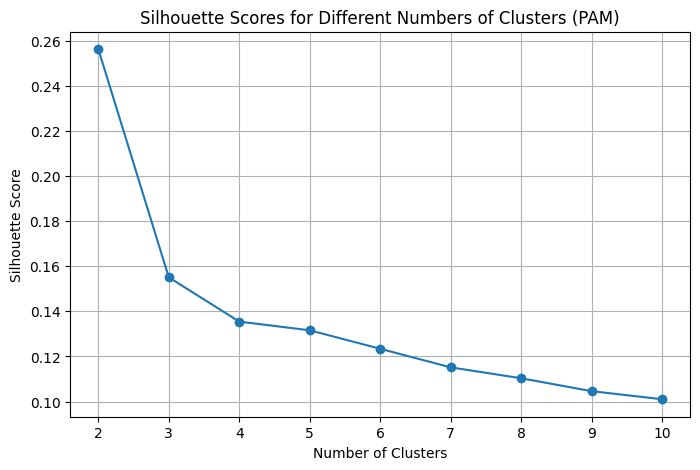

In [ ]:
silhouette_scores = []
k = range(2, 11)

for n_clusters in k:
    pam = KMedoids(n_clusters=n_clusters, random_state=42)
    cluster_labels = pam.fit_predict(data_pca)
    silhouette_avg = silhouette_score(data_pca, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"Silhouette Score for {n_clusters} clusters: {silhouette_avg}")

plt.figure(figsize=(8, 5))
plt.plot(k, silhouette_scores, marker='o')
plt.xticks(k)
plt.title('Silhouette Scores for Different Numbers of Clusters (PAM)')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [ ]:
optimal_k = k[np.argmax(silhouette_scores)]
print("Optimalan broj klastera:", optimal_k)

Optimalan broj klastera: 2


In [ ]:
optimal_k = 2

kmedoids = KMedoids(n_clusters=optimal_k, random_state=42).fit(data_pca)
cluster_labels = kmedoids.labels_

In [ ]:
ch_score = calinski_harabasz_score(df, cluster_labels)

In [ ]:
print(ch_score)

197.90848721426053


In [ ]:
medoids = kmedoids.cluster_centers_

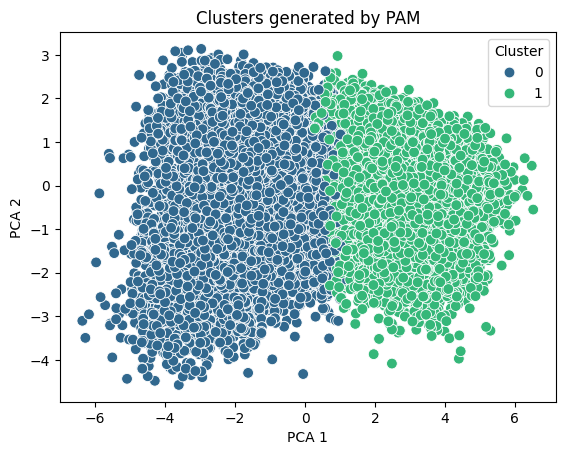

In [ ]:
import seaborn as sns

sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=cluster_labels, palette='viridis', s=60)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Clusters generated by PAM')
plt.legend(title='Cluster')
plt.show()